In [1]:
import pandas as pd
import os.path as op
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Users/mrenke/data/ds-stressrisk'
plot_folder_path = '/Users/mrenke/Desktop/StressRisk/figures/plots/fig_2'

sns.set_context('talk')

from stress_risk.behavior.utils import get_data

df = get_data()

/Users/mrenke/mambaforge/envs/behav_fit2_copy/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/behav_fit2_copy/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


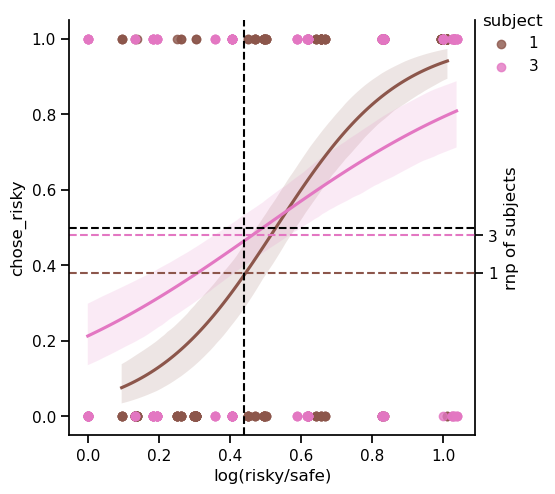

In [51]:
# concept illustration: psychometric curve
sns.set_context('notebook')

d = df.loc[([1,3])] # subject = 1

fac = sns.lmplot(d.reset_index(), x = 'log(risky/safe)', y = 'chose_risky', hue= 'subject',  logistic= True,palette=sns.color_palette()[5:] ) # col = 'subject', , legend_out=True
for ax in fac.axes.ravel():
    ax.axhline(.5, c='k', ls='--')
    ax.axvline(np.log(1.55), c='k', ls='--')

plt.axhline(.38, c=sns.color_palette()[5], ls='--')
plt.axhline(.48, c=sns.color_palette()[6], ls='--')

sns.move_legend(fac, "upper right")

ax = fac.facet_axis(0, 0)
ax2 = ax.secondary_yaxis('right')

tick_positions = [0.48,0.38]
tick_labels = ['3', '1']

ax2.set_yticks(tick_positions)
ax2.set_yticklabels(tick_labels)
ax2.set_ylabel('rnp of subjects')

# Show the plot
#plt.show()

plt.savefig(op.join(plot_folder_path, f'psychometric-curve_rnp_illustration_01'))


In [5]:
# probit model
# code from stress_risk/behavior/probit-model_
import arviz as az
import bambi

df['x'] = df['log(risky/safe)']

target_folder = op.join(bids_folder, 'derivatives', 'cogmodels')

n_model = 1
if n_model == 1:
    formulae = 'chose_risky ~ x*session*group + (x*session|subject)' # 1
elif n_model == 2:
    formulae = 'chose_risky ~ x*session:group + (x*session|subject)' # no main effect of group # 2
elif n_model == 3:
	formulae = 'chose_risky ~ x*session + session:group + x*session:group + (x*session|subject)' # 3

model = bambi.Model(formulae, link='probit', family='bernoulli', data=df.reset_index())
traces= az.from_netcdf(op.join(target_folder, f'bambi-RNP-fit_trace_model{n_model}.netcdf'))


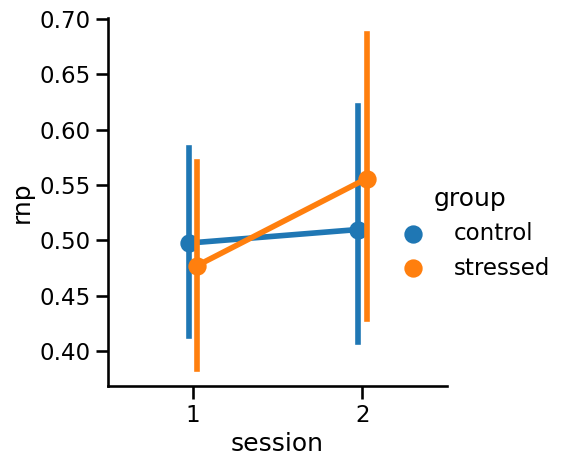

In [6]:
# plot rnp
from arviz import hdi
from stress_risk.behavior.utils import extract_rnp_precision

intercept, gamma = extract_rnp_precision(traces, model, df, True) # important 
rnp = np.clip(np.exp(intercept/gamma), 0, 1)

get_error_bar = lambda d: hdi(d.values)
tmp = rnp.stack([-1, -2])
tmp.columns = ['rnp']
tmp = tmp.reset_index()
p = sns.catplot(tmp, y='rnp', x='session', hue='group', kind='point',
            errorbar=get_error_bar, dodge=True) # legend=False
legend_labels = {"0": "control", "1": "stressed"}
for t, l in zip(p._legend.texts, legend_labels.values()):
    t.set_text(l)

#plt.title(f'model {n_model}') 
#plt.show(p) # saved png gets blank with those lines

plt.savefig(op.join(plot_folder_path, f'rnp_group-sesssion_model-{n_model}'))

In [9]:
# posterior chains
d = rnp.stack([1,2]).rename(mapper={'chose_risky_mean':'y'},axis=1).reset_index()

# sess-diff per group
for group in [0,1]:
    #col = sns.color_palette()[0] if group == 0 else  sns.color_palette()[0]
    group_name = 'stressed' if group == 1 else 'control'
    dd= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
    sns.histplot(dd, bins=50, color = sns.color_palette()[group])
    plt.axvline(0, c='k', ls='--')
    plt.xlabel('rnp: ses2 vs. ses1')    
    plt.title(f'group: {group_name}, p={np.round(np.mean(dd>0),3)}')
    np.mean(dd>0)
    plt.tight_layout()
    sns.despine()
    plt.savefig(op.join(plot_folder_path, f'rnp_posteriors_group{group}_ses1-ses2_model-{n_model}'))
    plt.close()
    # model-2 makes no sense here: d[(d['draw'] == 0) & (d['chain'] == 0) & (d['n_safe'] == 10) & (d['risky_first'] == True)], does not allow for session effect in group 0, so estimates are exaclty the same


# diff in diff
group = 0
dd_0= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
group = 1
dd_1= np.asarray(d[(d['session']==2) & (d['group']==group)]['y']) -  np.asarray(d[(d['session']==1) & (d['group']==group)]['y'])
dd = dd_1 - dd_0
sns.histplot(dd, bins=50, color = sns.color_palette()[4])
plt.axvline(0, c='k', ls='--')
plt.xlabel('rnp: diff in diff') #\n [(group1(ses2-ses1) - group0(ses2-ses1)]')
plt.title(f'p = {np.round(np.mean(dd>0),3)}')
sns.despine()
plt.tight_layout()
plt.savefig(op.join(plot_folder_path, f'rnp_posterior_diffOFdiff_model-{n_model}'))
plt.close()

/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:168: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ppc = ppc.groupby(['subject']+groupby).mean()
/Users/mrenke/git/stress_risk/stress_risk/behavior/utils.py:110: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_47518/570012525.py:9: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  plt.savefig(op.join(plot_folder_path, f'ppc_model-{n_model}'))
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_47518/570012525.py:9: MatplotlibDeprecationWarning: Support for passing numbers through unit conv

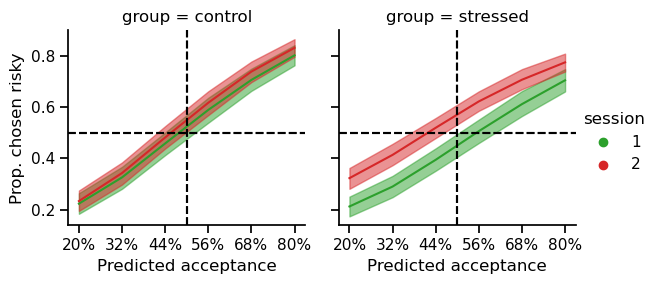

In [27]:
from stress_risk.behavior.utils import plot_ppc, format_bambi_ppc

ppc = format_bambi_ppc(traces, model, df)
p = ppc.reset_index('group').rename(mapper={'group':'group_int'},axis=1)
p['group'] = np.where(p['group_int'] == 0, 'control', 'stressed') # modify names of group

sns.set_context('notebook')
plot_ppc(df, p, level='group', plot_type=10)
plt.savefig(op.join(plot_folder_path, f'ppc_model-{n_model}'))
